# 📊 Exploratory Data Analysis (EDA)

## School Bullying Analysis using the CRDC 2021–22 Dataset

**Notebook:** 03 – Exploratory Data Analysis  
**Author:** Yoldas Erdem  
**Project:** Data Analytics & AI Bootcamp Capstone  

---

## Executive Summary

This notebook explores the cleaned CRDC Harassment and Bullying dataset after completion of the ETL pipeline.

The purpose is not to answer every research question yet. Instead, this notebook evaluates whether the cleaned dataset is reliable, identifies initial patterns, and prepares the analytical questions that will later be investigated in PostgreSQL, SQL, Tableau, and the final presentation.

The notebook follows a structured analytical flow:

1. **Dataset Understanding** – confirm the structure, completeness, and quality of the cleaned dataset.
2. **Data Exploration** – explore school metadata, bullying allegations, reported students, disciplined students, geographic patterns, distributions, and correlations.
3. **Key Findings & SQL Transition** – summarize the most important observations and translate them into SQL questions.

# Abstract

This notebook presents the Exploratory Data Analysis (EDA) of the 2021–22 Civil Rights Data Collection (CRDC) Harassment and Bullying dataset published by the U.S. Department of Education.

Following the completion of the ETL pipeline, the cleaned dataset is examined to evaluate its structure, quality, completeness, and overall reporting patterns before performing relational database analysis in PostgreSQL and developing interactive Tableau dashboards.

The objectives of this notebook are to:

- Understand the composition of the cleaned dataset.
- Assess data quality and completeness.
- Explore bullying allegation categories.
- Investigate reported and disciplined student groups.
- Identify geographic reporting patterns.
- Formulate analytical questions for the SQL phase.

Rather than providing definitive conclusions, this exploratory analysis establishes the analytical foundation for the PostgreSQL queries, Tableau dashboards, and final recommendations presented later in the project.



# 📖 Introduction

Following the completion of the ETL pipeline, this notebook marks the beginning of the analytical phase of the project.

The cleaned CRDC Harassment and Bullying dataset is explored to better understand its structure, assess its overall quality, and identify meaningful patterns before conducting SQL analysis and building interactive Tableau dashboards.

Rather than testing predefined hypotheses, the purpose of this notebook is to become familiar with the data, uncover potential relationships, and identify questions worth investigating in greater depth.

Exploratory Data Analysis (EDA) serves as a critical bridge between data preparation and statistical analysis. The findings documented throughout this notebook will directly inform the SQL queries, dashboard design, and final presentation.

---

## 🎯 Objectives

This notebook aims to:

- Understand the overall structure of the cleaned dataset.
- Verify that the ETL process produced a reliable analytical dataset.
- Explore the distribution of bullying allegations across different categories.
- Investigate demographic patterns among affected students.
- Examine disciplinary actions reported by schools.
- Identify geographic trends across states and school districts.
- Generate analytical questions for the SQL phase.
- Define potential visualizations for the Tableau dashboard.

# 🗺️ Notebook Roadmap

The exploratory analysis is organized into three major sections.

## Section 1 — Dataset Understanding

Gain an understanding of the dataset before beginning any analysis.

Topics include:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Metadata overview
- Summary statistics

## Section 2 — Data Exploration

Explore the main components of the CRDC dataset and identify meaningful patterns.

Topics include:

- School metadata
- Bullying allegations
- Reported students
- Disciplinary actions
- Geographic comparisons
- Distribution analysis
- Correlation analysis

## Section 3 — Key Findings & SQL Transition

Summarize the most important observations and prepare the analytical questions for the SQL phase.

# 🔄 Analytics Workflow

This notebook represents the third stage of the overall project workflow.

```text
Raw CRDC Dataset
        │
        ▼
ETL Pipeline
        │
        ▼
Clean Analytical Dataset
        │
        ▼
📍 Exploratory Data Analysis
        │
        ▼
PostgreSQL Database
        │
        ▼
SQL Analysis
        │
        ▼
Tableau Dashboard
        │
        ▼
Executive Presentation
```

# 1. Dataset Understanding

## Purpose

Before exploring individual variables, it is important to understand the overall structure and quality of the dataset.

This section provides a high-level overview of the cleaned CRDC dataset by examining its dimensions, data types, completeness, and basic descriptive statistics. These initial checks confirm that the ETL process produced a reliable analytical dataset and establish a foundation for the exploratory analyses that follow.

---

## Analysis Checklist

- Load the cleaned dataset
- Review dataset dimensions
- Inspect data types
- Examine missing values
- Verify duplicate records
- Review summary statistics
- Inspect the first observations

# 1.1 Load the Clean Dataset

## Purpose

The exploratory analysis begins by loading the cleaned dataset produced during the ETL pipeline.

Unlike the original CRDC dataset, this version contains standardized variable names, preserved identifier fields, and CRDC reserve codes converted to missing values (`NULL`). It serves as the primary analytical dataset used throughout the remainder of this project.

After loading the dataset, a preview of the first observations is displayed to verify that the data was imported successfully.

In [1]:
# =====================================================
# Import Required Libraries
# =====================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =====================================================
# Project Configuration
# =====================================================

# Define the project root directory.
# This assumes the notebook is stored inside the notebooks/ folder.
project_root = Path.cwd().parent

# Path to the cleaned dataset created during the ETL pipeline.
clean_data = project_root / "data" / "processed" / "crdc_bullying_clean.csv"

# Path used later if exports are needed.
exports_dir = project_root / "exports"

print("Clean dataset path:", clean_data)
print("Clean dataset exists:", clean_data.exists())

Clean dataset path: /Users/yoldaserdem/Downloads/capstone/School_Bullying_Capstone/data/processed/crdc_bullying_clean.csv
Clean dataset exists: True


In [3]:
# =====================================================
# Load the Clean Dataset
# =====================================================

# district_id and school_key are identifiers, not numeric measures.
# They are loaded as strings to preserve leading zeros.
df = pd.read_csv(
    clean_data,
    dtype={
        "district_id": str,
        "school_key": str
    },
    low_memory=False
)

# Display the first five records.
df.head()

,state_code,state,district_id,district,school_id,school,school_key,juvenile_justice_school,allegation_sex,allegation_orientation,...,disciplined_disability_multi_race_male,disciplined_disability_multi_race_female,total_disciplined_disability_male,total_disciplined_disability_female,disciplined_disability_english_learner_male,disciplined_disability_english_learner_female,disciplined_disability_idea_male,disciplined_disability_idea_female,disciplined_disability_section_504_male,disciplined_disability_section_504_female
0,AL,ALABAMA,0100002,Alabama Youth Services,99995,AUTAUGA CAMPUS,010000299995,Yes,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AL,ALABAMA,0100005,Albertville City,870,Albertville Middle School,010000500870,No,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AL,ALABAMA,0100005,Albertville City,871,Albertville High School,010000500871,No,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AL,ALABAMA,0100005,Albertville City,879,Albertville Intermediate School,010000500879,No,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AL,ALABAMA,0100005,Albertville City,889,Albertville Elementary School,010000500889,No,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 1.2 Dataset Overview

## Purpose

Before examining individual variables, it is essential to understand the overall structure of the dataset.

This section provides a high-level overview, including the number of observations, variables, data types, and memory usage. These statistics help verify that the dataset has been loaded correctly and provide context for the analyses that follow.

In [4]:
# =====================================================
# Dataset Summary
# =====================================================

dataset_summary = pd.DataFrame({
    "Metric": [
        "Schools / School Records (Rows)",
        "Variables (Columns)"
    ],
    "Value": [
        f"{df.shape[0]:,}",
        df.shape[1]
    ]
})

dataset_summary

,Metric,Value
0,Schools / School Records (Rows),"98,010"
1,Variables (Columns),159


In [5]:
# =====================================================
# Dataset Information
# =====================================================

# df.info() gives a compact overview of column count, data types,
# non-null counts, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98010 entries, 0 to 98009
Columns: 159 entries, state_code to disciplined_disability_section_504_female
dtypes: float64(151), int64(1), str(7)
memory usage: 118.9 MB


In [6]:
# =====================================================
# Summary Statistics
# =====================================================

# Transposing describe() makes the output easier to read because
# each variable appears as one row.
summary_statistics = df.describe().T

summary_statistics.head(15)

,count,mean,std,min,25%,50%,75%,max
school_id,98010.0,3926.152944,9765.355942,0.0,753.0,1785.0,4184.75,99999.0
allegation_sex,91902.0,0.641738,5.135084,0.0,0.0,0.0,0.00,1133.0
allegation_orientation,91902.0,0.251453,4.564510,0.0,0.0,0.0,0.00,1133.0
allegation_race,91902.0,0.456922,4.917722,0.0,0.0,0.0,0.00,1133.0
allegation_disability,91902.0,0.172564,4.562140,0.0,0.0,0.0,0.00,1133.0
allegation_religion,91902.0,0.029346,0.367293,0.0,0.0,0.0,0.00,43.0
allegation_atag,91777.0,0.000338,0.027017,0.0,0.0,0.0,0.00,5.0
allegation_budd,91777.0,0.000022,0.004668,0.0,0.0,0.0,0.00,1.0
allegation_cath,91777.0,0.000131,0.013203,0.0,0.0,0.0,0.00,2.0
allegation_east,91777.0,0.000044,0.006602,0.0,0.0,0.0,0.00,1.0


# 1.3 Variable Overview

## Purpose

Understanding the variables available in the dataset is an important first step in exploratory analysis.

This section categorizes the variables according to their analytical purpose. Organizing the dataset into logical groups provides a clearer understanding of its structure and establishes the foundation for the analyses performed throughout the remainder of this notebook.

The CRDC Harassment and Bullying dataset can be divided into four main categories:

- **Metadata** – School and district identifiers.
- **Allegations** – Reported harassment and bullying allegations.
- **Reported Students** – Students reported as affected by bullying.
- **Disciplined Students** – Students receiving disciplinary actions following reported incidents.

In [7]:
# =====================================================
# Categorize Variables
# =====================================================

metadata_cols = [
    "state_code",
    "state",
    "district_id",
    "district",
    "school_id",
    "school",
    "school_key",
    "juvenile_justice_school"
]

allegation_cols = [
    col for col in df.columns
    if col.startswith("allegation_")
]

reported_cols = [
    col for col in df.columns
    if col.startswith("reported_") or col.startswith("total_reported_")
]

disciplined_cols = [
    col for col in df.columns
    if col.startswith("disciplined_") or col.startswith("total_disciplined_")
]

In [8]:
# =====================================================
# Variable Category Summary
# =====================================================

variable_summary = pd.DataFrame({
    "Variable Category": [
        "Metadata",
        "Bullying Allegations",
        "Reported Students",
        "Disciplined Students"
    ],
    "Number of Variables": [
        len(metadata_cols),
        len(allegation_cols),
        len(reported_cols),
        len(disciplined_cols)
    ]
})

variable_summary.loc[len(variable_summary)] = [
    "Total",
    variable_summary["Number of Variables"].sum()
]

variable_summary

,Variable Category,Number of Variables
0,Metadata,8
1,Bullying Allegations,19
2,Reported Students,66
3,Disciplined Students,66
4,Total,159


### Interpretation

The cleaned dataset contains **159 analytical variables**, organized into four logical categories.

The majority of variables describe either **students reported as affected by bullying (66 variables)** or **students receiving disciplinary actions (66 variables)**. These two groups account for more than 80% of all variables and represent the primary focus of the analytical phase.

A smaller group of **19 allegation variables** records the different types of harassment and bullying reported by schools, while **8 metadata variables** provide the geographic and institutional context required for comparisons across schools, districts, and states.

This categorization provides a clear roadmap for the exploratory analysis that follows.

# 1.4 Missing Values

## Purpose

Missing values are an expected characteristic of the cleaned CRDC dataset.

During the ETL process, official CRDC reserve codes (e.g., `-3`, `-4`, `-5`, `-6`, `-9`, `-12`, and `-13`) were intentionally converted to missing values (`NULL`) to improve data quality and prevent these administrative codes from being interpreted as legitimate numerical values.

This section evaluates the overall completeness of the dataset and identifies where missing values remain.

In [9]:
# =====================================================
# Missing Value Summary
# =====================================================

missing_summary = pd.DataFrame({
    "Metric": [
        "Total Missing Values",
        "Columns with Missing Values",
        "Complete Columns"
    ],
    "Value": [
        df.isna().sum().sum(),
        (df.isna().sum() > 0).sum(),
        (df.isna().sum() == 0).sum()
    ]
})

missing_summary

,Metric,Value
0,Total Missing Values,446839
1,Columns with Missing Values,151
2,Complete Columns,8


In [10]:
# =====================================================
# Top Variables with Missing Values
# =====================================================

missing_columns = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing_columns.columns = [
    "Variable",
    "Missing Values"
]

missing_columns["Missing (%)"] = (
    missing_columns["Missing Values"]
    / len(df)
    * 100
).round(2)

missing_columns.head(15)

,Variable,Missing Values,Missing (%)
0,allegation_hind,6405,6.54
1,allegation_prot,6233,6.36
2,allegation_atag,6233,6.36
3,allegation_sikh,6233,6.36
4,allegation_othrel,6233,6.36
5,allegation_othchrn,6233,6.36
6,allegation_multi,6233,6.36
7,allegation_morm,6233,6.36
8,allegation_jwsh,6233,6.36
9,allegation_jwit,6233,6.36


### Interpretation

The cleaned dataset contains missing values across the analytical measurement variables, while the metadata columns are complete. This is expected because the ETL pipeline converted official CRDC reserve codes into `NULL` values.

The missing values should not be treated as errors or deleted automatically. They represent administrative reporting cases such as unavailable, not applicable, or suppressed data. Therefore, they will be retained as `NULL` values and handled carefully during SQL analysis and Tableau visualization.

A key analytical implication is that missing values should **not** be interpreted as zero. A zero indicates that a school reported no count for a given measure, while `NULL` indicates that the value was unavailable, suppressed, not applicable, or otherwise represented by an official CRDC reserve code.

# 1.5 Duplicate Records

## Purpose

Before conducting any analysis, it is important to verify that each observation represents a unique school-level record.

Duplicate records could distort summary statistics, aggregate calculations, and visualizations by counting the same school more than once. This section confirms whether duplicate observations are present in the cleaned dataset.

In [11]:
# =====================================================
# Duplicate Record Check
# =====================================================

duplicate_count = df.duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate Records"],
    "Value": [duplicate_count]
})

duplicate_summary

,Metric,Value
0,Duplicate Records,0


### Interpretation

No duplicate records were identified in the cleaned dataset.

This confirms that each row represents a unique school-level record and that the ETL pipeline preserved the original school-level structure without introducing duplicate observations. The dataset is therefore suitable for aggregation and comparative analysis.

# 1.6 Metadata Summary

## Purpose

The metadata variables provide important contextual information about the schools included in the dataset.

This section summarizes the overall coverage of the CRDC dataset by reporting the number of jurisdictions, school districts, school records, and juvenile justice schools represented in the cleaned dataset.

In [12]:
# =====================================================
# Metadata Summary
# =====================================================

metadata_summary = pd.DataFrame({
    "Metric": [
        "Jurisdictions",
        "School Districts",
        "School Records",
        "Juvenile Justice Schools"
    ],
    "Value": [
        df["state"].nunique(),
        df["district_id"].nunique(),
        len(df),
        (df["juvenile_justice_school"] == "Yes").sum()
    ]
})

metadata_summary

,Metric,Value
0,Jurisdictions,52
1,School Districts,17704
2,School Records,98010
3,Juvenile Justice Schools,882


### Interpretation

The cleaned dataset contains **98,010 school-level records** collected from **17,704 school districts** across **52 jurisdictions**.

Among these records, **882 schools** are identified as juvenile justice schools, allowing comparisons between traditional public schools and specialized educational settings.

The complete metadata provides the geographic and institutional context required to compare bullying patterns across schools, districts, and states throughout the remainder of the analysis.

# 1.7 Dataset Understanding Summary

## Key Findings

The initial assessment confirms that the cleaned CRDC dataset is suitable for exploratory analysis.

Key observations include:

- The dataset contains **98,010 school-level records** described by **159 analytical variables**.
- Variables are organized into four logical categories: metadata, bullying allegations, reported students, and disciplined students.
- All metadata fields are complete, providing reliable geographic and institutional identifiers.
- Missing values are expected and result from official CRDC reserve codes converted to `NULL` values during the ETL process.
- No duplicate records were identified.

Overall, the dataset demonstrates a high level of data quality and provides a reliable foundation for exploratory analysis, SQL querying, and dashboard development.

# 2. Data Exploration

## Purpose

After validating the structure and quality of the dataset, this section begins the actual exploratory analysis.

The goal is to identify meaningful patterns in the cleaned CRDC Harassment and Bullying dataset and generate analytical questions that can later be explored in SQL and visualized in Tableau.

This section focuses on five main areas:

- School metadata
- Bullying allegation categories
- Students reported as affected
- Students disciplined
- Geographic patterns

# 2.1 School Metadata

## Research Question 2.1

What types of schools are represented in the dataset?

This section explores the basic composition of the dataset, including juvenile justice schools and overall school coverage.

In [13]:
# =====================================================
# Juvenile Justice School Distribution
# =====================================================

jj_summary = (
    df["juvenile_justice_school"]
    .value_counts(dropna=False)
    .reset_index()
)

jj_summary.columns = ["Juvenile Justice School", "Number of School Records"]

jj_summary["Percentage"] = (
    jj_summary["Number of School Records"] / len(df) * 100
).round(2)

jj_summary

,Juvenile Justice School,Number of School Records,Percentage
0,No,97128,99.1
1,Yes,882,0.9


### Interpretation

Most schools in the dataset are traditional public schools, while a smaller subset are identified as juvenile justice schools.

This distinction is useful because juvenile justice schools may represent a different educational setting with different student populations, reporting practices, and disciplinary contexts. Later SQL analysis can compare these groups if relevant.

# 2.2 Bullying Allegations

## Research Question 2.2

Which types of bullying and harassment allegations are reported most frequently?

This section compares the five main allegation categories recorded in the CRDC dataset.

In [14]:
# =====================================================
# Main Allegation Category Totals
# =====================================================

main_allegation_cols = [
    "allegation_sex",
    "allegation_orientation",
    "allegation_race",
    "allegation_disability",
    "allegation_religion"
]

allegation_summary = (
    df[main_allegation_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

allegation_summary.columns = ["Allegation Type", "Total Allegations"]

allegation_summary["Allegation Type"] = (
    allegation_summary["Allegation Type"]
    .str.replace("allegation_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

allegation_summary

,Allegation Type,Total Allegations
0,Sex,58977.0
1,Race,41992.0
2,Orientation,23109.0
3,Disability,15859.0
4,Religion,2697.0


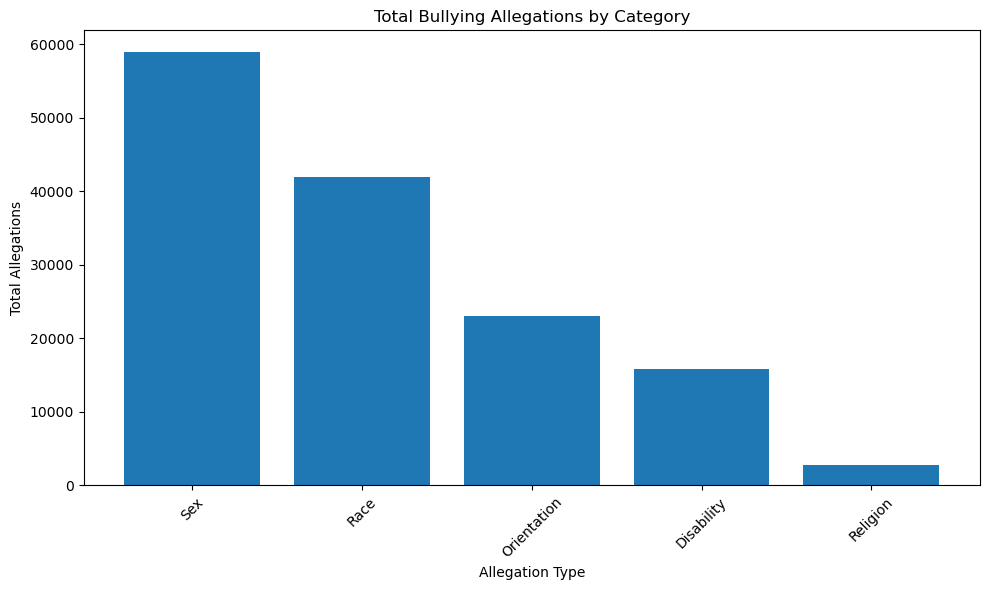

In [15]:
# =====================================================
# Bar Chart: Main Allegation Categories
# =====================================================

plt.figure(figsize=(10, 6))
plt.bar(
    allegation_summary["Allegation Type"],
    allegation_summary["Total Allegations"]
)

plt.title("Total Bullying Allegations by Category")
plt.xlabel("Allegation Type")
plt.ylabel("Total Allegations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The main allegation categories provide an initial view of which types of harassment and bullying are most frequently reported.

Categories with higher totals should become a priority for SQL analysis and Tableau visualizations because they represent the largest share of reported bullying allegations in the dataset.

Lower-frequency categories should not be ignored, but they may require more careful interpretation because small counts can be more sensitive to reporting differences across schools and districts.

# 2.3 Religion-Based Allegation Subcategories

## Research Question 2.3

Which religion-based allegation subcategories appear most frequently?

The CRDC dataset includes detailed subcategories for religion-based harassment and bullying allegations. This section explores those subcategories separately.

In [16]:
# =====================================================
# Religion Allegation Subcategory Totals
# =====================================================

religion_allegation_cols = [
    col for col in allegation_cols
    if col not in main_allegation_cols
]

religion_summary = (
    df[religion_allegation_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

religion_summary.columns = ["Religion Subcategory", "Total Allegations"]

religion_summary["Religion Subcategory"] = (
    religion_summary["Religion Subcategory"]
    .str.replace("allegation_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

# Convert technical CRDC abbreviation labels into readable labels.
religion_label_map = {
    "Jwsh": "Jewish",
    "Islm": "Muslim",
    "Othrel": "Other Religion",
    "Othchrn": "Other Christian",
    "Hind": "Hindu",
    "Multi": "Multiple Religions",
    "Atag": "Atheist/Agnostic",
    "Morm": "Mormon",
    "Prot": "Protestant",
    "Jwit": "Jehovah's Witness",
    "Cath": "Catholic",
    "Sikh": "Sikh",
    "East": "Eastern Orthodox",
    "Budd": "Buddhist"
}

religion_summary["Religion Subcategory"] = (
    religion_summary["Religion Subcategory"]
    .replace(religion_label_map)
)

religion_summary

,Religion Subcategory,Total Allegations
0,Jewish,546.0
1,Muslim,369.0
2,Other Religion,212.0
3,Other Christian,83.0
4,Hindu,44.0
5,Multiple Religions,33.0
6,Atheist/Agnostic,31.0
7,Mormon,19.0
8,Protestant,15.0
9,Jehovah's Witness,13.0


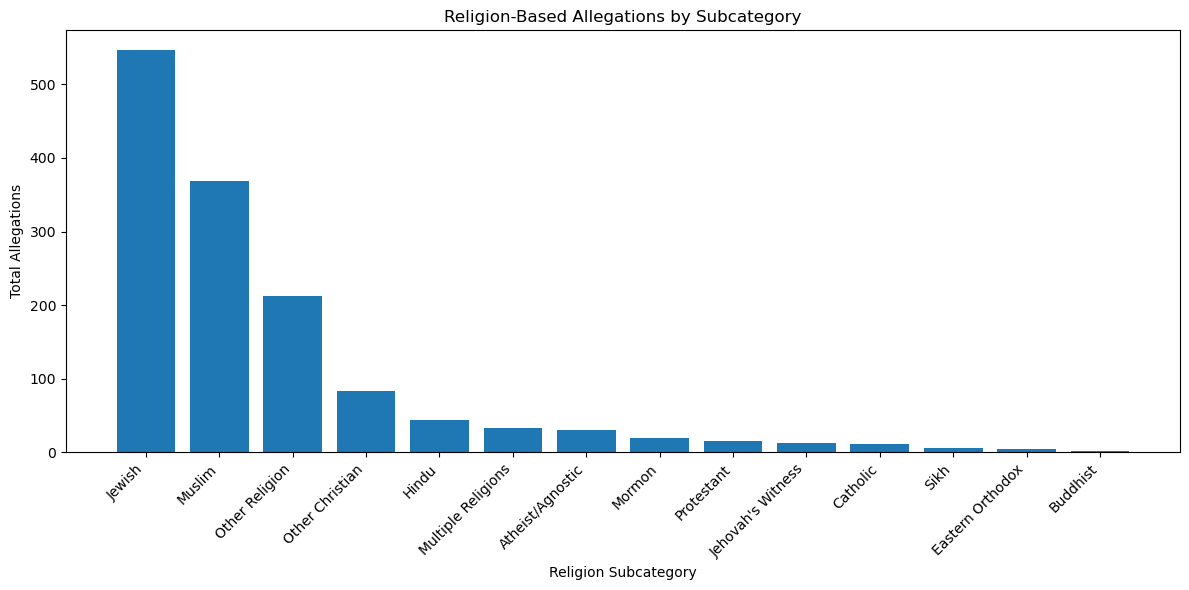

In [17]:
# =====================================================
# Bar Chart: Religion-Based Allegation Subcategories
# =====================================================

plt.figure(figsize=(12, 6))
plt.bar(
    religion_summary["Religion Subcategory"],
    religion_summary["Total Allegations"]
)

plt.title("Religion-Based Allegations by Subcategory")
plt.xlabel("Religion Subcategory")
plt.ylabel("Total Allegations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Religion-based allegation subcategories are much smaller in volume compared with the broader allegation categories.

This suggests that religion-based bullying may be better treated as a secondary or supporting analysis rather than the main focus of the dashboard. However, these variables remain useful for showing the level of detail available in the CRDC dataset.

# 2.4 Schools Reporting Any Allegations

## Research Question 2.4

How many schools report at least one bullying or harassment allegation?

This section distinguishes between schools that report no allegations and schools that report at least one allegation in any main category.

In [18]:
# =====================================================
# Schools with Any Main Allegation
# =====================================================

# Create a total allegation measure across the five main allegation categories.
df["total_main_allegations"] = df[main_allegation_cols].sum(axis=1, skipna=True)

# Flag school records with at least one main allegation.
df["has_any_allegation"] = df["total_main_allegations"] > 0

schools_with_allegations = pd.DataFrame({
    "Metric": [
        "Schools with at least one allegation",
        "Schools with zero allegations"
    ],
    "Value": [
        df["has_any_allegation"].sum(),
        (~df["has_any_allegation"]).sum()
    ]
})

schools_with_allegations["Percentage"] = (
    schools_with_allegations["Value"] / len(df) * 100
).round(2)

schools_with_allegations

/var/folders/r8/8pgq659n1c5db2p68_rcb9rh0000gn/T/ipykernel_59572/4263389949.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_main_allegations"] = df[main_allegation_cols].sum(axis=1, skipna=True)
/var/folders/r8/8pgq659n1c5db2p68_rcb9rh0000gn/T/ipykernel_59572/4263389949.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_any_allegation"] = df["total_main_allegations"] > 0


,Metric,Value,Percentage
0,Schools with at least one allegation,23668,24.15
1,Schools with zero allegations,74342,75.85


### Interpretation

This summary shows whether reported bullying allegations are widespread across many schools or concentrated in a smaller subset of schools.

If many schools report zero allegations, this does not necessarily mean bullying did not occur. It may also reflect differences in reporting practices, school size, documentation processes, or local policy definitions.

This is an important limitation to mention in the final analysis.

# 2.5 Reported Students

## Research Question 2.5

Which student groups are most frequently reported as affected by bullying?

The CRDC dataset includes student counts by demographic group. This section focuses on the total reported student variables to understand which groups appear most frequently in reported bullying records.

In [19]:
# =====================================================
# Total Reported Student Variables
# =====================================================

total_reported_cols = [
    col for col in reported_cols
    if col.startswith("total_reported_")
]

reported_summary = (
    df[total_reported_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

reported_summary.columns = ["Reported Student Group", "Total Reported Students"]

reported_summary["Reported Student Group"] = (
    reported_summary["Reported Student Group"]
    .str.replace("total_reported_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

reported_summary

,Reported Student Group,Total Reported Students
0,Sex Female,26725.0
1,Race Male,17036.0
2,Sex Male,16619.0
3,Race Female,12013.0
4,Disability Male,5565.0
5,Disability Female,2905.0


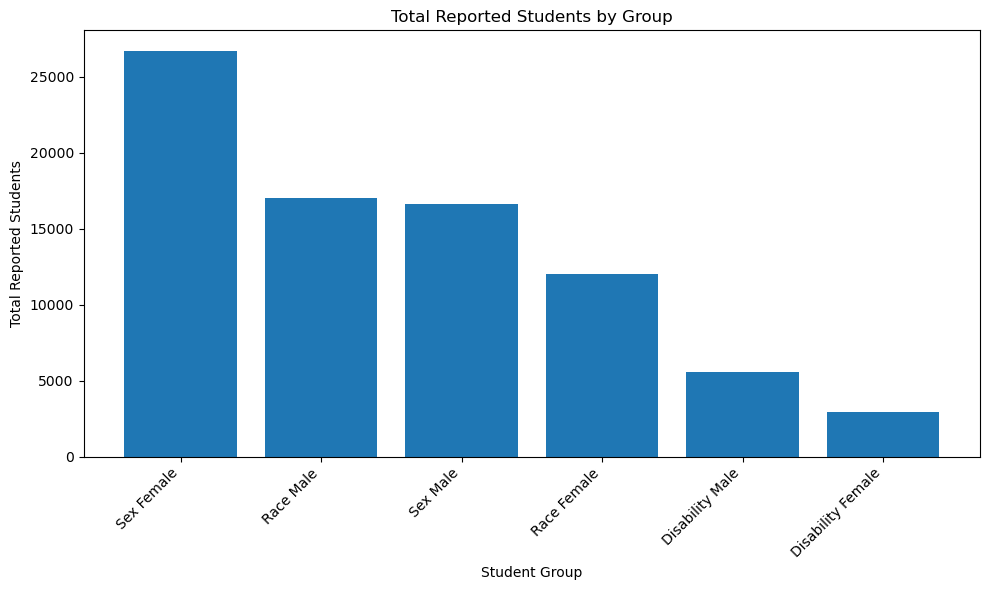

In [20]:
# =====================================================
# Bar Chart: Reported Student Groups
# =====================================================

plt.figure(figsize=(10, 6))
plt.bar(
    reported_summary["Reported Student Group"],
    reported_summary["Total Reported Students"]
)

plt.title("Total Reported Students by Group")
plt.xlabel("Student Group")
plt.ylabel("Total Reported Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Reported student counts provide a first view of which student groups appear most frequently in bullying-related records.

The group labels combine the allegation basis and student sex. For example, **Sex Female** means female students reported as affected by sex-based harassment or bullying.

These values should be interpreted as aggregate school-level counts, not confirmed individual-level victim records. Groups with higher reported counts should be explored further in SQL, especially when comparing allegations, reported students, and disciplinary actions.

# 2.6 Disciplined Students

## Research Question 2.6

Which student groups are most frequently recorded as disciplined in relation to bullying and harassment?

This section summarizes the total disciplined student variables to understand how disciplinary actions are distributed across student groups.

In [21]:
# =====================================================
# Total Disciplined Student Variables
# =====================================================

total_disciplined_cols = [
    col for col in disciplined_cols
    if col.startswith("total_disciplined_")
]

disciplined_summary = (
    df[total_disciplined_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

disciplined_summary.columns = ["Disciplined Student Group", "Total Disciplined Students"]

disciplined_summary["Disciplined Student Group"] = (
    disciplined_summary["Disciplined Student Group"]
    .str.replace("total_disciplined_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

disciplined_summary

,Disciplined Student Group,Total Disciplined Students
0,Sex Male,51035.0
1,Race Male,34693.0
2,Disability Male,13213.0
3,Sex Female,10736.0
4,Race Female,9500.0
5,Disability Female,4931.0


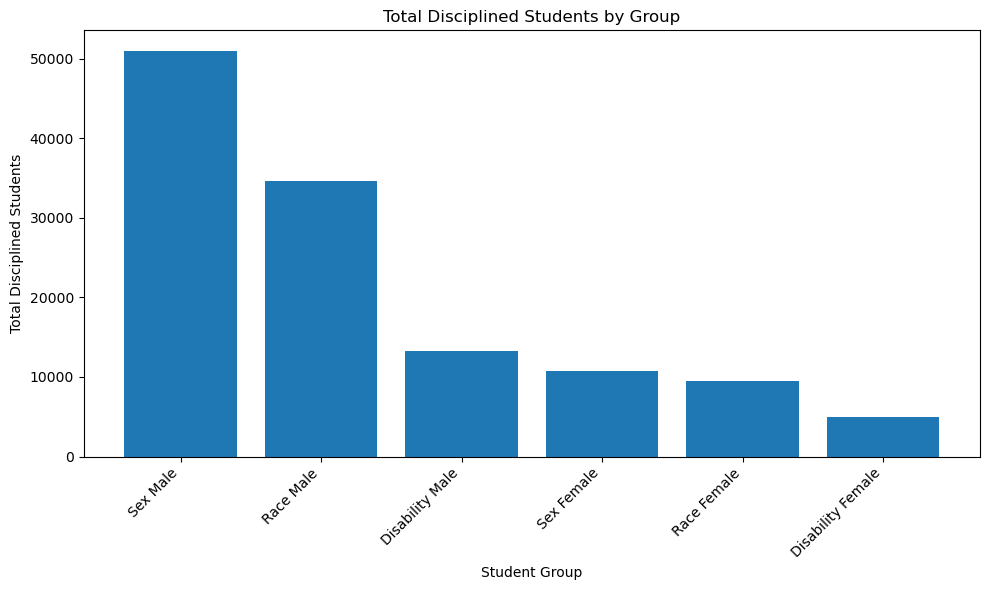

In [22]:
# =====================================================
# Bar Chart: Disciplined Student Groups
# =====================================================

plt.figure(figsize=(10, 6))
plt.bar(
    disciplined_summary["Disciplined Student Group"],
    disciplined_summary["Total Disciplined Students"]
)

plt.title("Total Disciplined Students by Group")
plt.xlabel("Student Group")
plt.ylabel("Total Disciplined Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Disciplined student counts show how schools reported disciplinary outcomes connected to bullying and harassment incidents.

These counts are not linked one-to-one with individual allegations. A school may report allegations and disciplinary outcomes in the same category, but the dataset does not provide incident-level records that directly connect a specific allegation to a specific disciplinary action.

For this reason, later SQL analysis should compare patterns at an aggregate level rather than treating allegations and disciplinary actions as directly matched events.

# 2.7 Allegations vs. Disciplined Students

## Research Question 2.7

How do reported allegations compare with disciplinary actions at an aggregate level?

This section compares total main allegations with total disciplined student counts to understand whether the two measures move together at a high level.

In [23]:
# =====================================================
# Aggregate Allegations and Discipline Summary
# =====================================================

total_allegations = df[main_allegation_cols].sum().sum()
total_disciplined_students = df[total_disciplined_cols].sum().sum()

allegation_discipline_summary = pd.DataFrame({
    "Metric": [
        "Total Main Allegations",
        "Total Disciplined Students"
    ],
    "Value": [
        total_allegations,
        total_disciplined_students
    ]
})

allegation_discipline_summary

,Metric,Value
0,Total Main Allegations,142634.0
1,Total Disciplined Students,124108.0


### Interpretation

This comparison gives a high-level view of the relationship between reported allegations and disciplinary outcomes.

However, the two measures should not be interpreted as a direct conversion rate. Allegation counts and disciplined student counts are related conceptually, but the dataset does not link them at the individual incident level.

This reinforces the need to analyze them as separate but related reporting measures.

# 2.8 Geographic Overview

## Research Question 2.8

How do reported bullying allegations vary across jurisdictions?

This section aggregates allegations by state or jurisdiction to identify geographic variation in reported bullying and harassment patterns.

In [24]:
# =====================================================
# Total Allegations by Jurisdiction
# =====================================================

state_allegations = (
    df.groupby("state", as_index=False)["total_main_allegations"]
    .sum()
    .sort_values("total_main_allegations", ascending=False)
)

state_allegations.head(15)

,state,total_main_allegations
13,ILLINOIS,15208.0
32,NEW YORK,14427.0
4,CALIFORNIA,12742.0
48,WASHINGTON,8724.0
30,NEW JERSEY,7801.0
44,TEXAS,5619.0
25,MISSOURI,4798.0
9,FLORIDA,4568.0
50,WISCONSIN,4428.0
38,PENNSYLVANIA,4174.0


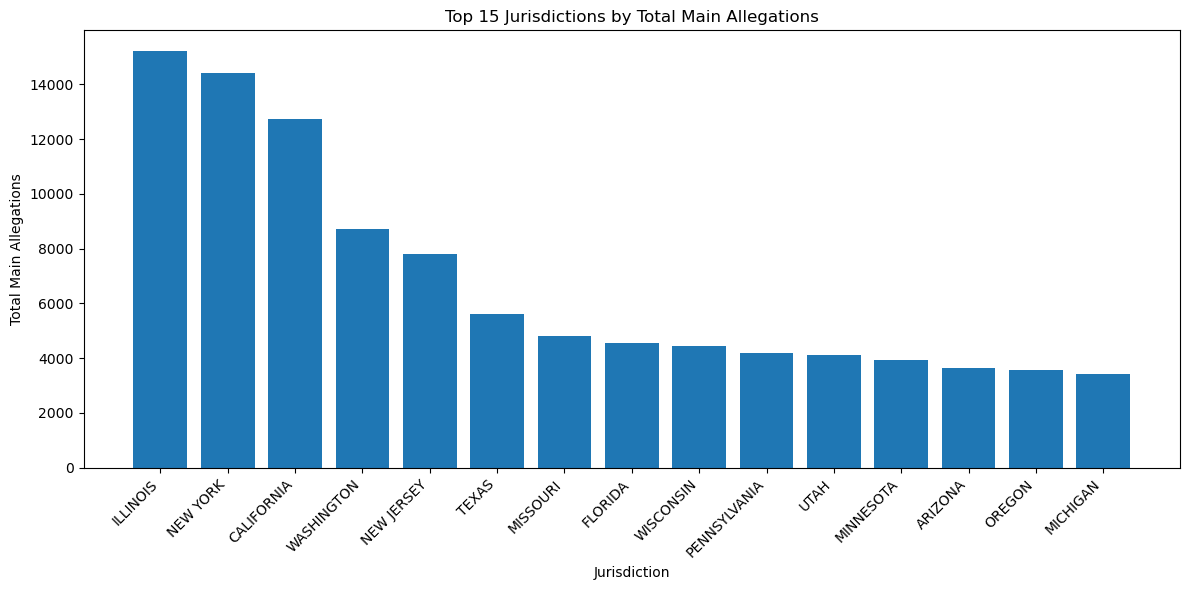

In [25]:
# =====================================================
# Bar Chart: Top Jurisdictions by Allegations
# =====================================================

top_states = state_allegations.head(15)

plt.figure(figsize=(12, 6))
plt.bar(
    top_states["state"],
    top_states["total_main_allegations"]
)

plt.title("Top 15 Jurisdictions by Total Main Allegations")
plt.xlabel("Jurisdiction")
plt.ylabel("Total Main Allegations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The geographic overview identifies jurisdictions with the highest reported allegation counts.

At this stage, these results should be interpreted as raw totals. Larger jurisdictions may naturally report more incidents because they have more schools and students. Later SQL analysis should calculate normalized rates where possible, such as allegations per school record, to support fairer comparisons.

# 2.9 District-Level Overview

## Research Question 2.9

Which school districts report the highest number of bullying allegations?

This section identifies districts with the highest aggregate allegation counts.

In [26]:
# =====================================================
# Top Districts by Main Allegations
# =====================================================

district_allegations = (
    df.groupby(["state", "district"], as_index=False)["total_main_allegations"]
    .sum()
    .sort_values("total_main_allegations", ascending=False)
)

district_allegations.head(15)

,state,district,total_main_allegations
4202,ILLINOIS,DeKalb CUSD 428,9844.0
11389,NEW YORK,NEW YORK CITY PUBLIC SCHOOLS,8407.0
17052,WASHINGTON,Wapato School District,4116.0
16342,UTAH,Alpine District,1756.0
2645,CALIFORNIA,San Francisco Unified,1335.0
16365,UTAH,Davis District,1119.0
14779,SOUTH CAROLINA,Beaufort 01,916.0
1806,CALIFORNIA,Hacienda la Puente Unified,882.0
8712,MISSOURI,INDEPENDENCE 30,878.0
2640,CALIFORNIA,San Diego Unified,875.0


### Interpretation

District-level aggregation helps identify where reported bullying allegations are concentrated.

As with state-level totals, these figures should be interpreted carefully because larger districts are likely to report higher raw counts. Later SQL analysis can build on this by comparing raw totals with counts per school record or by focusing on ranked district-level summaries.

# 2.10 Distribution of School-Level Allegations

## Research Question 2.10

Are bullying allegations evenly distributed across schools, or concentrated among a smaller number of schools?

This section examines the distribution of total allegations across school records.

In [27]:
# =====================================================
# Distribution Summary for Total Main Allegations
# =====================================================

allegation_distribution_summary = pd.DataFrame({
    "Metric": [
        "Minimum",
        "Median",
        "Mean",
        "75th Percentile",
        "Maximum"
    ],
    "Value": [
        df["total_main_allegations"].min(),
        df["total_main_allegations"].median(),
        round(df["total_main_allegations"].mean(), 2),
        df["total_main_allegations"].quantile(0.75),
        df["total_main_allegations"].max()
    ]
})

allegation_distribution_summary

,Metric,Value
0,Minimum,0.00
1,Median,0.00
2,Mean,1.46
3,75th Percentile,0.00
4,Maximum,4532.00


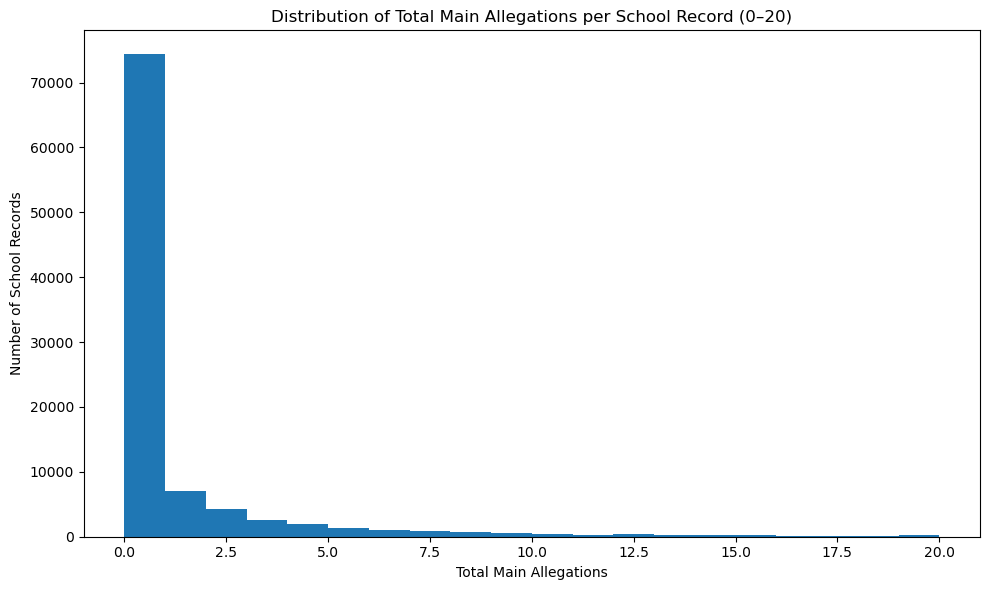

In [28]:
# =====================================================
# Histogram: Filtered Distribution of Total Main Allegations
# =====================================================

# The full distribution is heavily affected by a small number of extreme outliers.
# A filtered 0-20 view makes the typical school-level pattern easier to inspect.
filtered_allegations = df[df["total_main_allegations"] <= 20]

plt.figure(figsize=(10, 6))
plt.hist(filtered_allegations["total_main_allegations"], bins=20)

plt.title("Distribution of Total Main Allegations per School Record (0–20)")
plt.xlabel("Total Main Allegations")
plt.ylabel("Number of School Records")
plt.tight_layout()
plt.show()

### Interpretation

The distribution of allegations is highly skewed.

Most schools report zero or very few allegations, while a smaller number of schools report much higher counts. The median and 75th percentile are both zero, which indicates that reported allegations are concentrated among a subset of schools.

Because the distribution is highly skewed, the full histogram is dominated by a small number of extreme outliers. A filtered view between 0 and 20 allegations is more useful for understanding the typical school-level pattern.

For Tableau, this distribution may be better visualized using filtered views, ranked charts, or outlier-focused views rather than a standard histogram alone.

# 2.11 Correlation Exploration

## Research Question 2.11

Which numerical variables appear most strongly related to overall bullying allegations?

This section provides an initial correlation check between total main allegations and selected reported or disciplined student measures.

In [29]:
# =====================================================
# Correlation with Total Main Allegations
# =====================================================

numeric_cols = df.select_dtypes(include="number").columns

correlations = (
    df[numeric_cols]
    .corr()["total_main_allegations"]
    .sort_values(ascending=False)
    .reset_index()
)

correlations.columns = ["Variable", "Correlation with Total Main Allegations"]

correlations.head(15)

,Variable,Correlation with Total Main Allegations
0,total_main_allegations,1.000000
1,allegation_orientation,0.970561
2,allegation_disability,0.968949
3,allegation_race,0.960871
4,allegation_sex,0.941824
5,disciplined_disability_black_female,0.741511
6,disciplined_sex_black_female,0.687323
7,disciplined_race_black_female,0.668903
8,disciplined_disability_black_male,0.633408
9,disciplined_disability_idea_male,0.551468


### Interpretation

Correlation analysis provides an initial view of which variables move together with total reported allegations.

The strongest correlations are partly expected because `total_main_allegations` is calculated from the main allegation variables. Therefore, this output is mainly useful for identifying related disciplinary and reported-student variables, not for causal interpretation.

These relationships should be interpreted cautiously. Correlation does not imply causation, and because the dataset is school-level and administrative, strong relationships may reflect school size, reporting practices, or shared category definitions.

The most strongly correlated variables can help prioritize SQL queries and dashboard views.

# 2.12 Section 2 Summary

## Key Observations

The exploratory analysis reveals several important patterns:

- Bullying and harassment allegations vary substantially across categories.
- Sex-based and race-based allegations appear among the largest reported categories.
- Religion-based allegations are much smaller in volume compared with the broader allegation categories.
- Only a subset of schools report at least one allegation, while many school records report zero allegations.
- Reported student and disciplined student counts provide related but distinct perspectives.
- Allegations and disciplinary actions should not be interpreted as one-to-one linked events.
- Geographic totals vary across jurisdictions and districts, but raw counts should be normalized before drawing strong comparisons.
- Allegation counts are highly concentrated, with many schools reporting few or no allegations and a smaller number of schools reporting much higher counts.

## Implications for SQL Analysis

The SQL phase should focus on:

- Ranking allegation categories by total reported counts.
- Comparing allegations across jurisdictions and districts.
- Calculating allegations per school record.
- Comparing reported student groups and disciplined student groups.
- Exploring disciplinary patterns at an aggregate level.
- Identifying concentration points and potential outliers.
- Creating summary tables suitable for Tableau dashboards.

# 3. Key Findings & Transition to SQL

## Purpose

This final section summarizes the most important observations from the exploratory analysis and translates them into concrete SQL analysis questions.

The EDA phase identifies what appears important. The SQL phase will quantify these patterns more rigorously, create reusable analytical tables, and prepare the project for Tableau dashboard development.

# 3.1 Key Findings

The exploratory analysis identified several important characteristics of the cleaned CRDC Harassment and Bullying dataset.

## Dataset Quality

- The cleaned dataset contains **98,010 school-level records** and **159 analytical variables**.
- Metadata fields are complete and reliable for grouping by jurisdiction, district, and school.
- Missing values are expected and result from CRDC reserve codes converted to `NULL` during the ETL process.
- No duplicate records were identified.

## Initial Analytical Patterns

- Allegations are not evenly distributed across schools.
- Many schools report zero allegations, while a smaller number of schools report much higher counts.
- Main allegation categories differ substantially in volume.
- Reported student counts and disciplined student counts should be interpreted as related but separate measures.
- Geographic variation exists, but raw totals should be normalized before making strong comparisons.

# 3.2 Questions for SQL Analysis

The SQL phase should move beyond descriptive summaries and focus on deeper analytical questions.

## Category-Level Questions

- Which allegation categories represent the largest share of all reported allegations?
- How does the allegation category mix vary across jurisdictions?
- Which categories are most associated with higher disciplinary counts?

## Geographic Questions

- Which jurisdictions have the highest total allegations?
- Which jurisdictions have the highest allegations per school record?
- Which districts report unusually high allegation counts?
- Are high totals concentrated in a small number of districts?

## Response and Discipline Questions

- How do disciplined student counts compare with reported allegation counts?
- Are some categories associated with higher disciplinary counts?
- Which student groups appear most frequently in disciplined student counts?

## Concentration and Outlier Questions

- What percentage of total allegations comes from the top 1%, 5%, or 10% of schools?
- Which schools or districts appear as potential outliers?
- Are high-count schools concentrated in specific jurisdictions?

## Tableau Preparation Questions

- Which SQL summary tables should feed the dashboard?
- Which metrics should appear as KPI cards?
- Which rankings should become bar charts?
- Which geographic summaries should become map or state-level views?

# 3.3 Proposed SQL Output Tables

To support Tableau dashboard development, the SQL phase should create reusable summary tables.

Recommended outputs:

| Output Table | Purpose |
|---|---|
| `category_summary` | Total allegations by main allegation category |
| `state_summary` | Allegations, reported students, and disciplined students by jurisdiction |
| `district_summary` | District-level allegation and discipline summaries |
| `school_summary` | School-level totals and outlier indicators |
| `response_summary` | Aggregated reported vs. disciplined student counts |
| `concentration_summary` | Share of allegations contributed by top schools or districts |

These tables will make Tableau development faster, cleaner, and more consistent.

# 3.4 Recommended Tableau Dashboard Direction

Based on the exploratory analysis, the Tableau dashboard should focus on a concise analytical story rather than displaying every variable.

Recommended dashboard sections:

1. **Overview KPI Cards**
   - Total school records
   - Total allegations
   - Schools with at least one allegation
   - Total disciplined students

2. **Allegation Category Breakdown**
   - Bar chart showing main allegation categories

3. **Geographic View**
   - State/jurisdiction ranking or map
   - Allegations per school record where possible

4. **Reported vs. Disciplined Comparison**
   - Aggregate comparison between reported affected students and disciplined students

5. **District / School Concentration**
   - Top districts or schools by allegation count
   - Optional outlier table

6. **Key Takeaways**
   - Short text box summarizing the most important findings and limitations

# 3.5 EDA Conclusion

The exploratory analysis confirms that the cleaned CRDC dataset is suitable for deeper analysis.

The dataset has strong coverage, reliable metadata, and enough structure to support comparisons across categories, schools, districts, and jurisdictions. At the same time, the analysis highlights important limitations: reported allegations are not incident-level records, disciplinary counts are not directly linked one-to-one with allegations, and raw geographic totals must be normalized before drawing strong conclusions.

The next stage of the project is to import the cleaned dataset into PostgreSQL and use SQL to create structured analytical summaries for Tableau and the final presentation.

# 3. Conclusions and Transition to SQL

## Overall Conclusions

The exploratory analysis confirmed that the cleaned CRDC dataset is well structured, highly complete, and suitable for advanced analytical work.

The analysis identified several important patterns:

- Sex-based and race-based allegations account for the largest share of reported incidents.
- Most schools reported no allegations, while a relatively small subset reported substantially higher counts.
- Geographic variation exists across jurisdictions and districts.
- Reported student counts and disciplined student counts describe related but distinct aspects of school reporting.
- Missing values reflect official CRDC reserve codes converted to NULL values during the ETL process and should not be interpreted as data quality errors.

## Transition to SQL

The next phase of the project moves from exploratory analysis to relational analysis in PostgreSQL.

The SQL notebook will investigate:

1. State-level allegation rankings and normalized reporting rates.
2. District-level comparisons and outlier detection.
3. Relationships between allegation categories and disciplinary actions.
4. Differences across demographic groups.
5. Summary tables and views prepared for Tableau dashboards.

The EDA has therefore established a reliable analytical foundation and identified the key research questions that will be answered during the SQL phase.

